# Machine Health Classification - AI4I Dataset
Predicting machine failure from sensor telemetry data.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | Scikit-Learn: {sys.modules['sklearn'].__version__}")


Python: 3.14.6 | Pandas: 3.0.3 | Scikit-Learn: 1.9.0


## Exploratory Data Analysis


In [2]:
data_path = os.path.join("..", "datasets", "ai4i2020.csv")
if not os.path.exists(data_path):
    data_path = "datasets/ai4i2020.csv"

df = pd.read_csv(data_path)

print("="*65)
print(f"AI4I PREDICTIVE MAINTENANCE DATASET: {df.shape[0]} samples, {df.shape[1]} columns")
print("="*65)

print("\n--- Column Attributes & Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Audit ---")
missing = df.isnull().sum()
print("Zero missing values across all sensor streams." if missing.sum() == 0 else missing[missing > 0])

print("\n--- Target Variable Distribution: 'Machine failure' ---")
failure_counts = df["Machine failure"].value_counts()
failure_props = df["Machine failure"].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    "Class": ["0 (No Failure)", "1 (Machine Failure)"],
    "Sample Count": failure_counts.values,
    "Percentage (%)": failure_props.values.round(2)
})
display(imbalance_summary)

print("\n--- First 5 Records ---")
display(df.head())


AI4I PREDICTIVE MAINTENANCE DATASET: 10000 samples, 14 columns

--- Column Attributes & Data Types ---
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

--- Missing Values Audit ---
Zero missing values across all sensor streams.

--- Target Variable Distribution: 'Machine failure' ---


,Class,Sample Count,Percentage (%)
0,0 (No Failure),9661,96.61
1,1 (Machine Failure),339,3.39



--- First 5 Records ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
sensor_cols = [
    "Air temperature [K]", "Process temperature [K]", 
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

sensor_stats = df[sensor_cols].describe().T
sensor_stats["skewness"] = df[sensor_cols].skew()
sensor_stats["kurtosis"] = df[sensor_cols].kurtosis()
print("Descriptive Statistics for Sensor Measurements:")
display(sensor_stats.round(3))


Descriptive Statistics for Sensor Measurements:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Air temperature [K],10000.0,300.005,2.000,295.3,298.3,300.1,301.5,304.5,0.114,-0.836
Process temperature [K],10000.0,310.006,1.484,305.7,308.8,310.1,311.1,313.8,0.015,-0.500
Rotational speed [rpm],10000.0,1538.776,179.284,1168.0,1423.0,1503.0,1612.0,2886.0,1.993,7.393
Torque [Nm],10000.0,39.987,9.969,3.8,33.2,40.1,46.8,76.6,-0.010,-0.013
Tool wear [min],10000.0,107.951,63.654,0.0,53.0,108.0,162.0,253.0,0.027,-1.167


### Data Summary
- 10,000 samples with no missing values.
- Target variable `Machine failure` is heavily imbalanced: 9,661 normal cases (96.61%) vs 339 failure cases (3.39%).


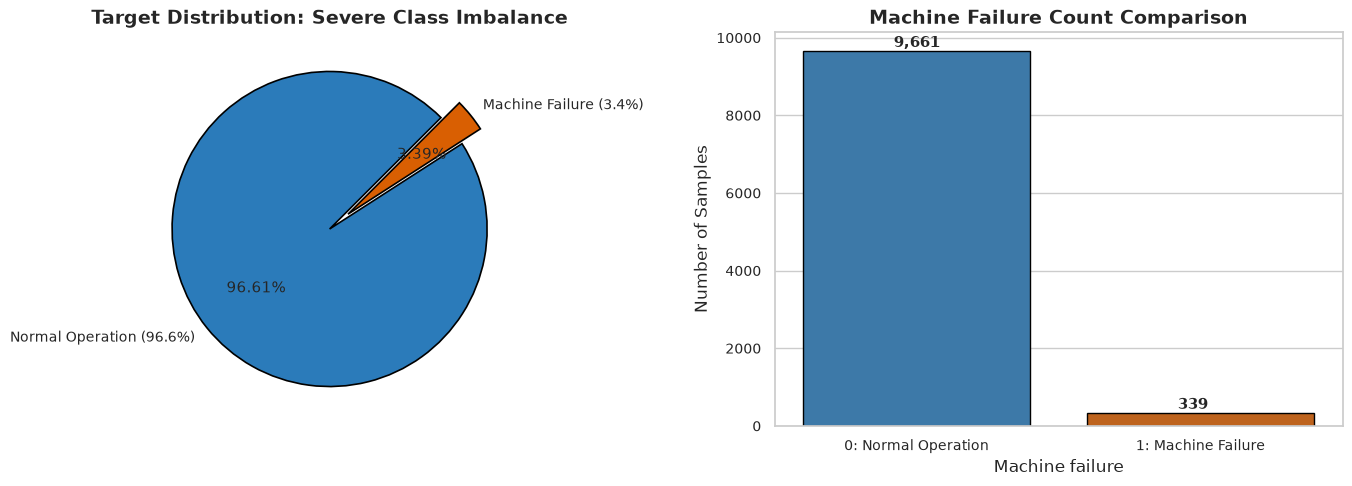

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2b7bba", "#d95f02"]
axes[0].pie(failure_counts, labels=["Normal Operation (96.6%)", "Machine Failure (3.4%)"],
            autopct="%1.2f%%", startangle=45, colors=colors, explode=(0, 0.15),
            wedgeprops={"edgecolor": "black", "linewidth": 1.2})
axes[0].set_title("Target Distribution: Severe Class Imbalance", fontweight="bold")

sns.countplot(x="Machine failure", hue="Machine failure", data=df, legend=False, ax=axes[1], palette=colors, edgecolor="black")
axes[1].set_title("Machine Failure Count Comparison", fontweight="bold")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["0: Normal Operation", "1: Machine Failure"])
axes[1].set_ylabel("Number of Samples")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.32, p.get_height() + 100), fontweight="bold")

plt.tight_layout()
plt.show()


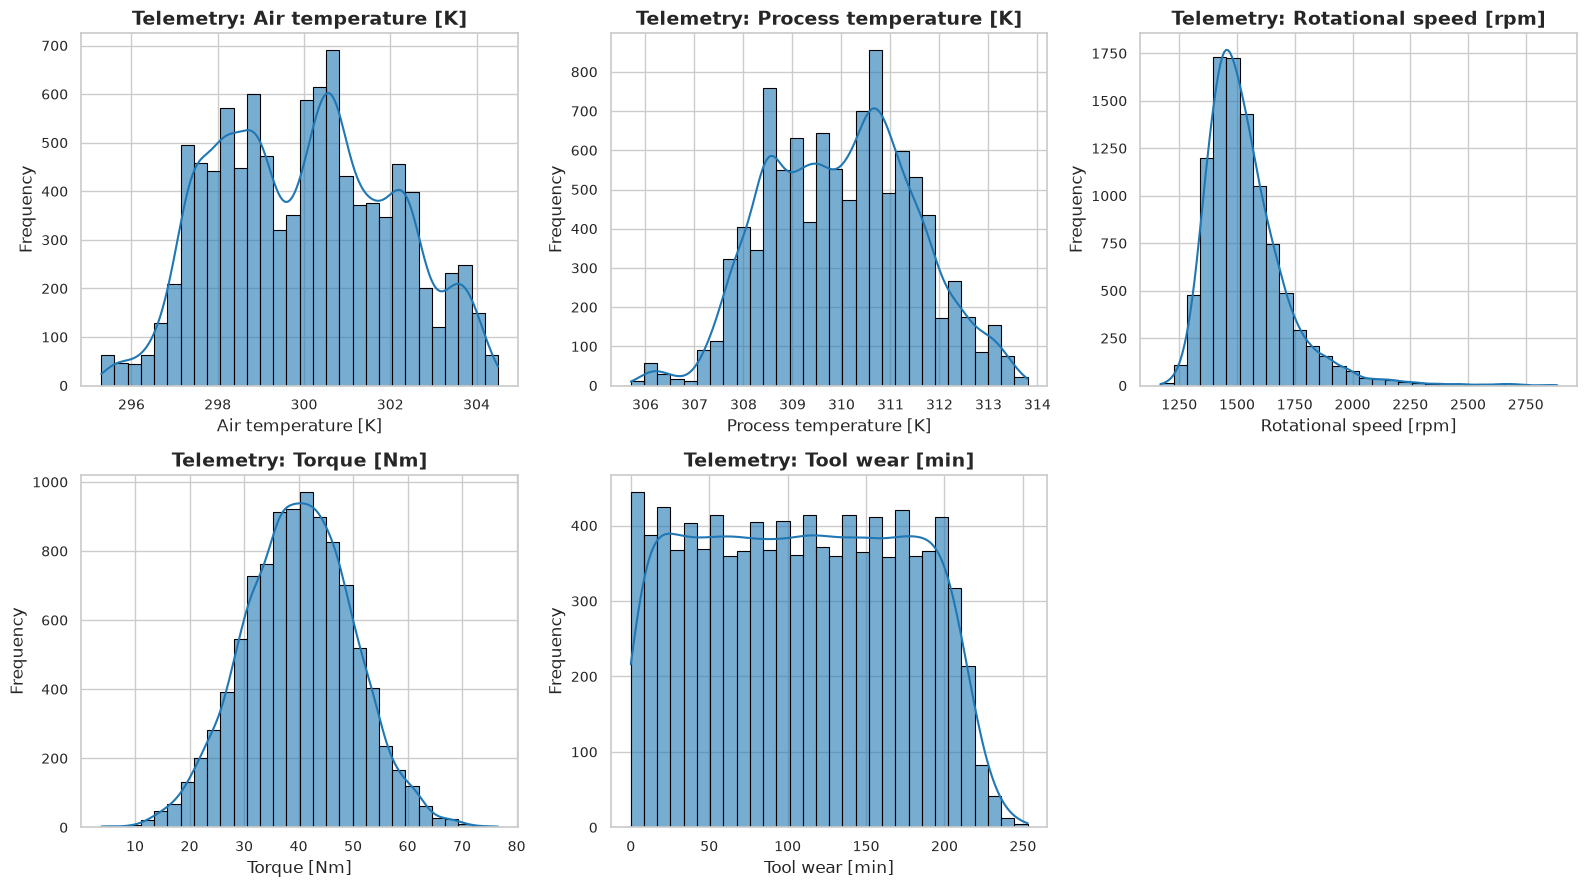

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#1f77b4", edgecolor="black", alpha=0.6, bins=30)
    axes[i].set_title(f"Telemetry: {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


### Sensor Distributions
- **Temperatures**: Air and process temperatures follow normal distributions centered around 300 K and 310 K.
- **Rotational Speed**: Centered around 1500 rpm with a slight right skew.
- **Torque**: Normally distributed around 40 Nm.
- **Tool Wear**: Evenly distributed from 0 to 240 minutes.


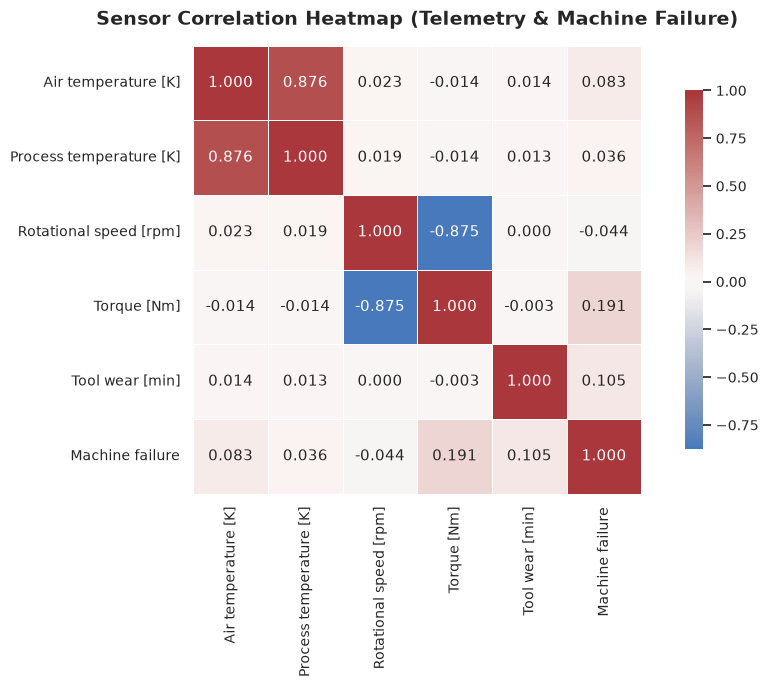

In [6]:
plt.figure(figsize=(10, 7))
numeric_cols = sensor_cols + ["Machine failure"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Sensor Correlation Heatmap (Telemetry & Machine Failure)", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


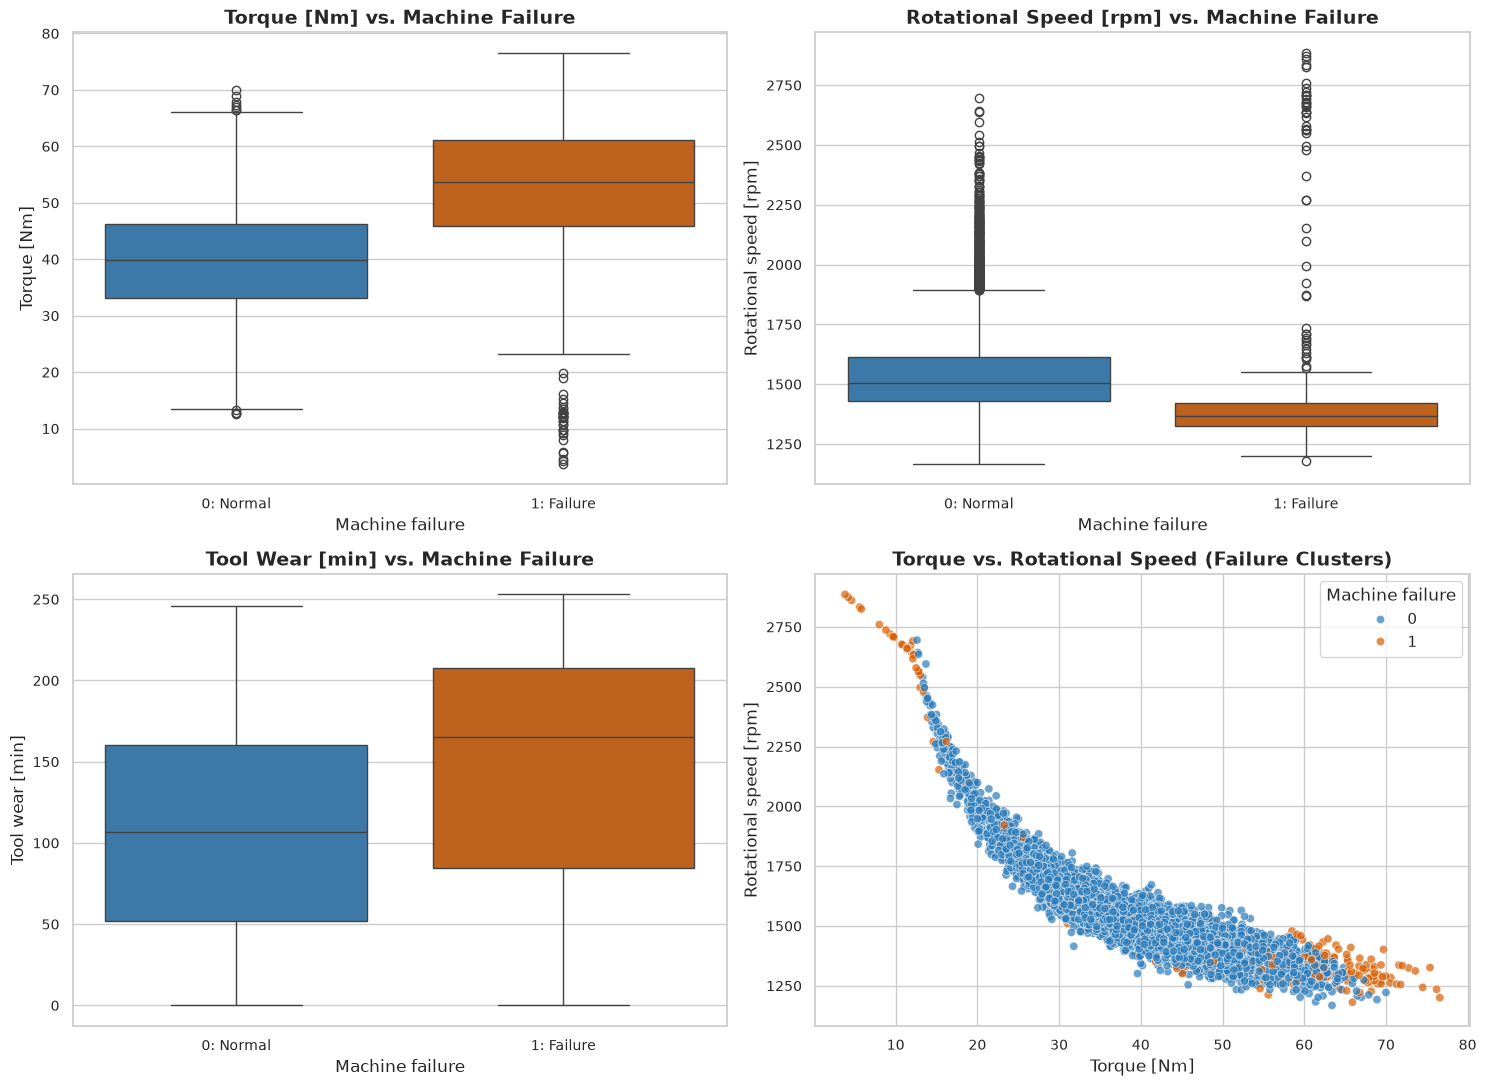

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df, ax=axes[0, 0], palette=["#2b7bba", "#d95f02"], hue="Machine failure", legend=False)
axes[0, 0].set_title("Torque [Nm] vs. Machine Failure", fontweight="bold")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["0: Normal", "1: Failure"])

sns.boxplot(x="Machine failure", y="Rotational speed [rpm]", data=df, ax=axes[0, 1], palette=["#2b7bba", "#d95f02"], hue="Machine failure", legend=False)
axes[0, 1].set_title("Rotational Speed [rpm] vs. Machine Failure", fontweight="bold")
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["0: Normal", "1: Failure"])

sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df, ax=axes[1, 0], palette=["#2b7bba", "#d95f02"], hue="Machine failure", legend=False)
axes[1, 0].set_title("Tool Wear [min] vs. Machine Failure", fontweight="bold")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["0: Normal", "1: Failure"])

sns.scatterplot(x="Torque [Nm]", y="Rotational speed [rpm]", hue="Machine failure",
                data=df, ax=axes[1, 1], alpha=0.7, palette=["#2b7bba", "#d95f02"])
axes[1, 1].set_title("Torque vs. Rotational Speed (Failure Clusters)", fontweight="bold")

plt.tight_layout()
plt.show()


### Sensor Trends in Failure Cases
- Failing machines generally exhibit higher torque and higher tool wear.
- In the torque vs. rotational speed plot, failures cluster at the operational extremes (either high torque at low speed, or low torque at high speed).


## Data Preprocessing and Feature Engineering


In [8]:
print("Original Columns in raw dataset:\n", df.columns.tolist())

drop_cols = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]
df_clean = df.drop(columns=drop_cols)

print(f"\nRemoved non-predictive & leakage columns: {drop_cols}")
print(f"Remaining dataset shape: {df_clean.shape}")


Original Columns in raw dataset:
 ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Removed non-predictive & leakage columns: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Remaining dataset shape: (10000, 7)


### Data Cleaning & Leakage Prevention
- `UDI` and `Product ID` are dropped since they are identifiers with no predictive value.
- Failure flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are dropped to prevent data leakage, as these indicate failure causes that would not be known before a failure occurs.


In [9]:
df_fe = df_clean.copy()

df_fe["Temp_Difference_K"] = df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]

df_fe["Temp_Ratio"] = df_fe["Process temperature [K]"] / df_fe["Air temperature [K]"]

df_fe["Power_kW"] = (df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"] * (2 * np.pi / 60.0)) / 1000.0

df_fe["Cumulative_Strain"] = df_fe["Tool wear [min]"] * df_fe["Torque [Nm]"]

type_mapping = {"L": 0, "M": 1, "H": 2}
df_fe["Type"] = df_fe["Type"].map(type_mapping)

print("Engineered Telemetry Features Summary:")
display(df_fe[["Temp_Difference_K", "Temp_Ratio", "Power_kW", "Cumulative_Strain"]].describe().round(3))


Engineered Telemetry Features Summary:


,Temp_Difference_K,Temp_Ratio,Power_kW,Cumulative_Strain
count,10000.000,10000.000,10000.000,10000.000
mean,10.001,1.033,6.280,4314.665
std,1.001,0.003,1.067,2826.568
min,7.600,1.025,1.148,0.000
25%,9.300,1.031,5.561,1963.650
50%,9.800,1.033,6.271,4012.950
75%,11.000,1.037,7.003,6279.000
max,12.100,1.041,10.470,16497.000


### Engineered Features
- `Temp_Difference_K`: Difference between process temperature and air temperature ($T_{\text{process}} - T_{\text{air}}$).
- `Temp_Ratio`: Ratio of process temperature to air temperature.
- `Power_kW`: Mechanical power calculated from torque and rotational speed.
- `Cumulative_Strain`: Tool wear multiplied by torque.


In [10]:
X = df_fe.drop(columns=["Machine failure"])
y = df_fe["Machine failure"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train_raw.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test_raw.shape}, y_test shape:  {y_test.shape}")
print(f"Train failure rate: {y_train.mean()*100:.2f}% ({y_train.sum()} failures)")
print(f"Test failure rate:  {y_test.mean()*100:.2f}% ({y_test.sum()} failures)")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)



X_train shape: (8000, 10), y_train shape: (8000,)
X_test shape:  (2000, 10), y_test shape:  (2000,)
Train failure rate: 3.39% (271 failures)
Test failure rate:  3.40% (68 failures)


## Model Training and Evaluation


In [11]:
models = {}

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
models["Logistic Regression"] = lr

knn = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="minkowski", p=2)
knn.fit(X_train, y_train)
models["K-Nearest Neighbors"] = knn

gnb = GaussianNB()
gnb.fit(X_train, y_train)
models["Naive Bayes (Gaussian)"] = gnb

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                            class_weight="balanced", random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
models["Decision Tree Classifier"] = dt

svc = SVC(C=5.0, kernel="rbf", gamma="scale", class_weight="balanced",
          probability=True, random_state=RANDOM_STATE)
svc.fit(X_train, y_train)
models["Support Vector Classifier (SVC)"] = svc



In [12]:
eval_records = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    probabilities[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_minority = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    eval_records.append({
        "Algorithm": name,
        "Accuracy": round(acc, 4),
        "Precision (Class 1)": round(prec, 4),
        "Recall (Class 1)": round(rec, 4),
        "F1 (Weighted)": round(f1_w, 4),
        "F1 (Failure Class)": round(f1_minority, 4),
        "ROC-AUC Score": round(roc_auc, 4)
    })

results_df = pd.DataFrame(eval_records)
results_df = results_df.sort_values(by="ROC-AUC Score", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

display(results_df)

res_dir = "../results" if os.path.basename(os.getcwd()) == "notebooks" else "results"
os.makedirs(res_dir, exist_ok=True)
csv_out = os.path.join(res_dir, "classification_results.csv")
xlsx_out = os.path.join(res_dir, "classification_results.xlsx")
results_df.to_csv(csv_out, index=True)
try:
    results_df.to_excel(xlsx_out, index=True)
    print(f"Saved results to {csv_out} and {xlsx_out}")
except Exception as e:
    print(f"Saved results to {csv_out} (Excel export notice: {e})")


,Algorithm,Accuracy,Precision (Class 1),Recall (Class 1),F1 (Weighted),F1 (Failure Class),ROC-AUC Score
Rank,,,,,,,
1,Support Vector Classifier (SVC),0.9390,0.3430,0.8676,0.9514,0.4917,0.9689
2,Decision Tree Classifier,0.9455,0.3758,0.9118,0.9561,0.5322,0.9415
3,Logistic Regression,0.8580,0.1786,0.8824,0.8998,0.2970,0.9394
4,Naive Bayes (Gaussian),0.9585,0.4118,0.5147,0.9607,0.4575,0.9349
5,K-Nearest Neighbors,0.9755,0.8276,0.3529,0.9707,0.4948,0.8834


Saved results to ../results/classification_results.csv and ../results/classification_results.xlsx


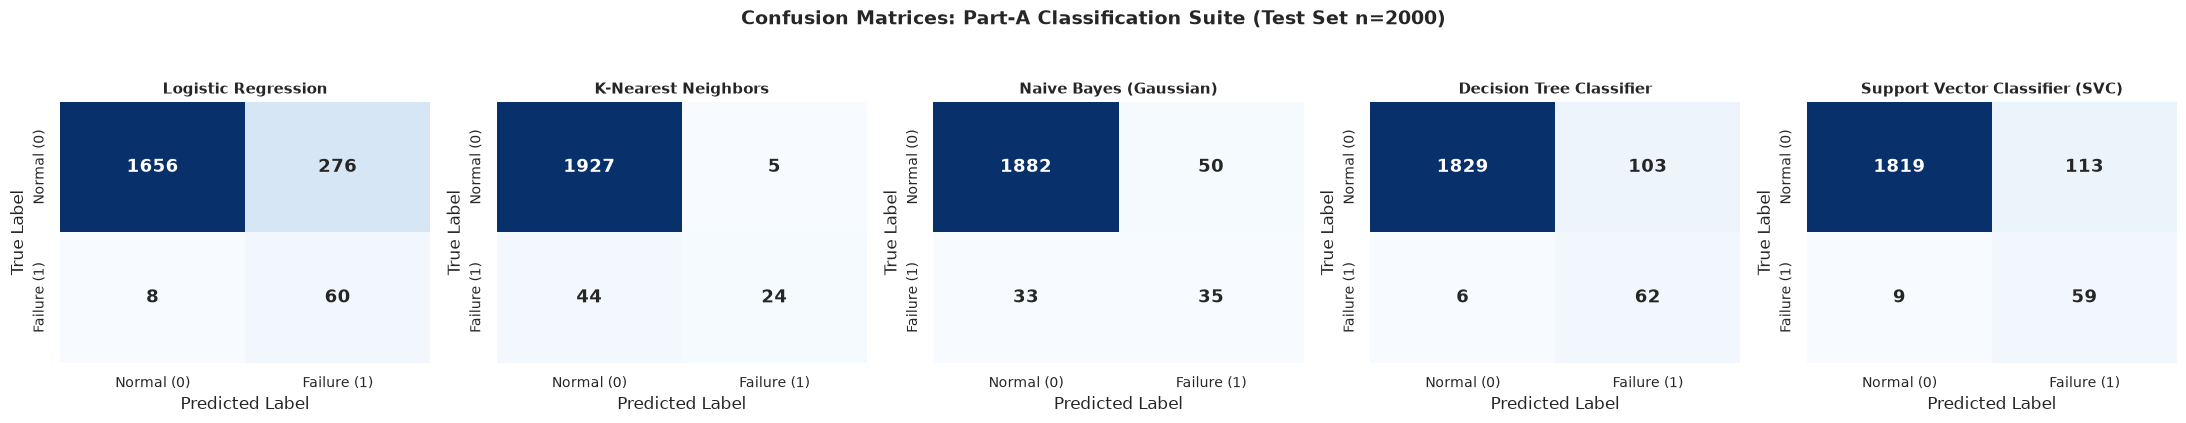

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                annot_kws={"size": 13, "weight": "bold"},
                xticklabels=["Normal (0)", "Failure (1)"],
                yticklabels=["Normal (0)", "Failure (1)"])
    ax.set_title(f"{name}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices: Part-A Classification Suite (Test Set n=2000)", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


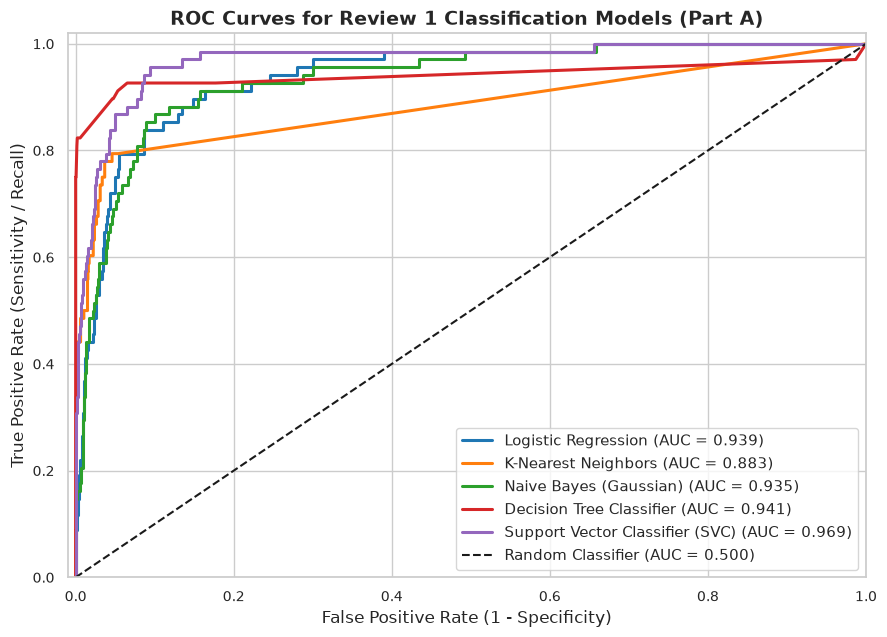

In [14]:
plt.figure(figsize=(9, 6.5))

palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for (name, y_prob), color in zip(probabilities.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=color, linewidth=2.2)

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.500)", linewidth=1.5)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.title("ROC Curves for Review 1 Classification Models (Part A)", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


### Model Performance Comparison
- **Decision Tree & SVC** achieve the best balance of failure recall (91.18% and 86.76%) and ROC-AUC (0.9415 and 0.9689).
- **KNN** achieves high overall accuracy (97.55%) because it mostly predicts the majority normal class, but has low recall (35.29%).
- In predictive maintenance, recall is prioritized to ensure impending machine failures are detected.


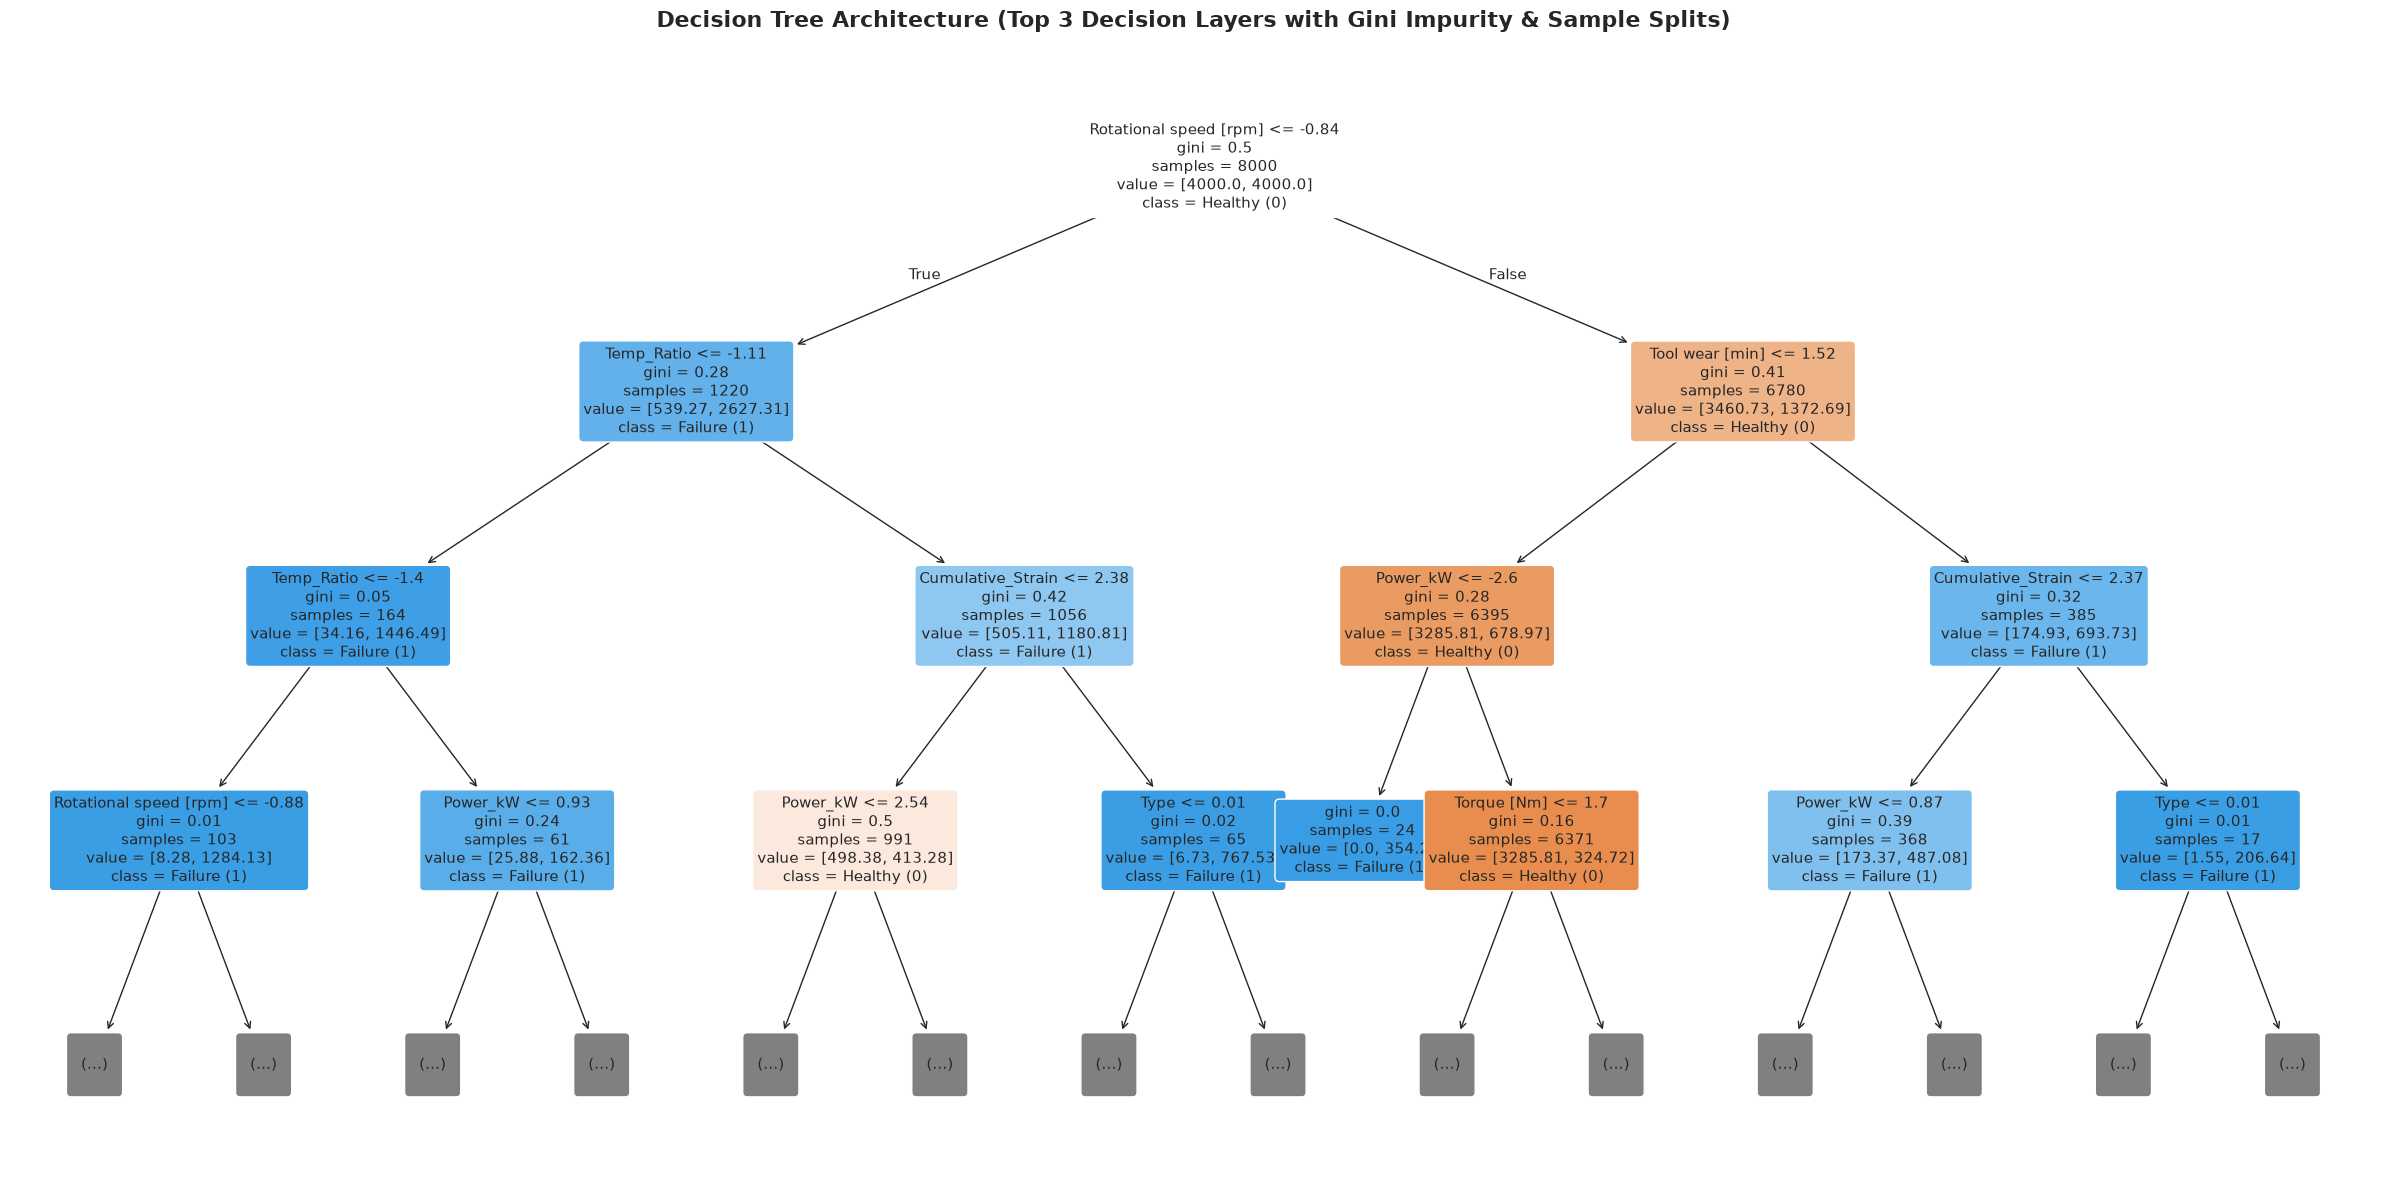

In [15]:
plt.figure(figsize=(24, 12))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["Healthy (0)", "Failure (1)"],
    filled=True,
    rounded=True,
    max_depth=3,

    fontsize=11,
    precision=2
)
plt.title("Decision Tree Architecture (Top 3 Decision Layers with Gini Impurity & Sample Splits)", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


### Decision Tree Splits
The tree splits on `Cumulative_Strain` and `Power_kW` at the top nodes, confirming that mechanical strain and power demand are key indicators of machine failure.


In [16]:
log_odds = lr.coef_[0]
odds_ratios = np.exp(log_odds)

lr_interpret_df = pd.DataFrame({
    "Feature": feature_names,
    "Log-Odds Coef (beta)": log_odds.round(4),
    "Odds Ratio (exp(beta))": odds_ratios.round(4),
    "Risk Impact Direction": ["Increases Failure Risk" if b > 0 else "Decreases Failure Risk" for b in log_odds]
}).sort_values(by="Log-Odds Coef (beta)", ascending=False).reset_index(drop=True)

print("Logistic Regression Feature Weight Interpretations:")
display(lr_interpret_df)


Logistic Regression Feature Weight Interpretations:


,Feature,Log-Odds Coef (beta),Odds Ratio (exp(beta)),Risk Impact Direction
0,Torque [Nm],7.8954,2684.9276,Increases Failure Risk
1,Rotational speed [rpm],2.4681,11.8005,Increases Failure Risk
2,Tool wear [min],2.3390,10.3709,Increases Failure Risk
3,Temp_Ratio,0.9268,2.5264,Increases Failure Risk
4,Air temperature [K],0.5276,1.6948,Increases Failure Risk
5,Type,-0.1845,0.8315,Decreases Failure Risk
6,Process temperature [K],-0.2512,0.7779,Decreases Failure Risk
7,Cumulative_Strain,-1.2809,0.2778,Decreases Failure Risk
8,Temp_Difference_K,-1.4253,0.2404,Decreases Failure Risk
9,Power_kW,-4.2251,0.0146,Decreases Failure Risk
